# Task 2: Unemployment Analysis with Python
Analyzing unemployment trends and the impact of Covid-19 across Indian regions.

Dataset Preview:
           Region       Date  Estimated Unemployment Rate (%)
0  Andhra Pradesh 2019-05-31                            10.55
1  Andhra Pradesh 2019-06-30                            12.71
2  Andhra Pradesh 2019-07-31                             5.18
3  Andhra Pradesh 2019-08-31                             7.05
4  Andhra Pradesh 2019-09-30                            11.84

Shape: (144, 3)

Descriptive Stats:
                      Date  Estimated Unemployment Rate (%)
count                  144                       144.000000
mean   2020-02-14 08:00:00                        12.820139
min    2019-05-31 00:00:00                         3.690000
25%    2019-09-30 00:00:00                         7.672500
50%    2020-02-14 12:00:00                        11.200000
75%    2020-06-30 00:00:00                        14.560000
max    2020-10-31 00:00:00                        38.710000
std                    NaN                         7.008873


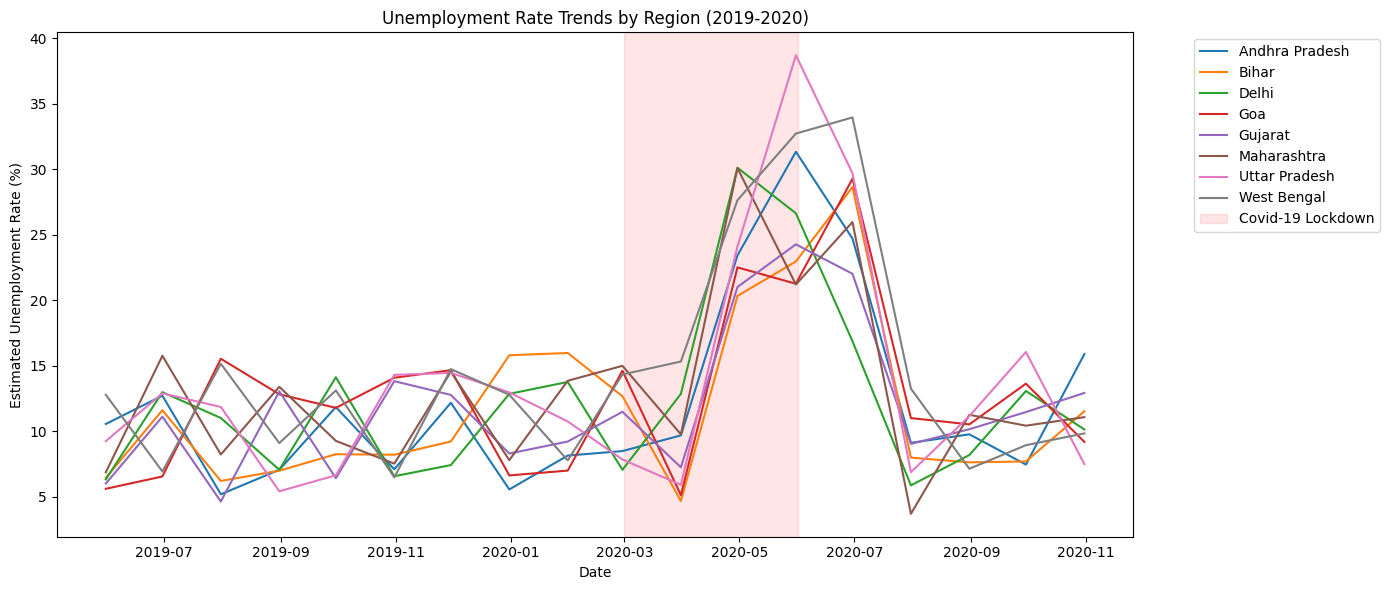

C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_10344\1137224429.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_by_region.values, y=avg_by_region.index, palette='Reds_r')


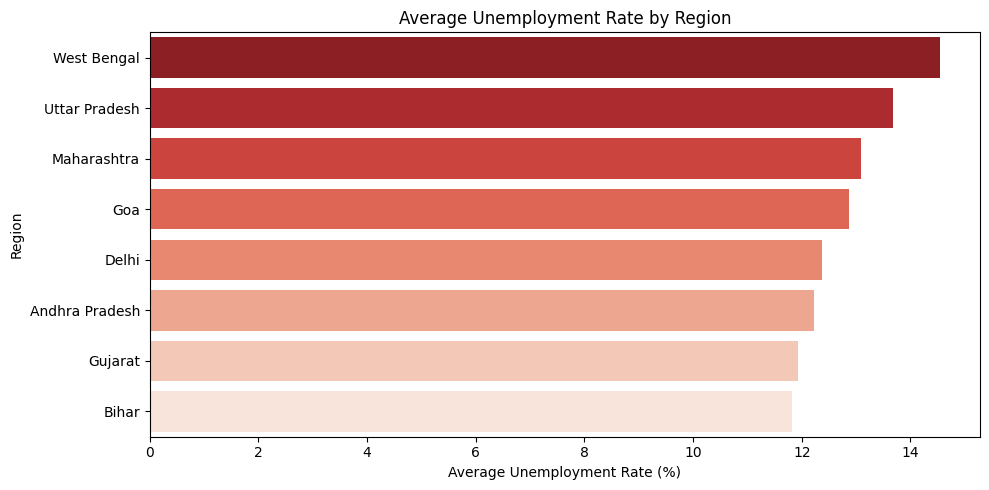

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Generating synthetic data for demonstration
np.random.seed(42)
regions = ['Andhra Pradesh', 'Bihar', 'Delhi', 'Goa', 'Gujarat', 'Maharashtra', 'Uttar Pradesh', 'West Bengal']
dates = pd.date_range(start='2019-05-31', end='2020-10-31', freq='ME')

data = []
for region in regions:
    for date in dates:
        base_rate = np.random.uniform(5, 15)
        if date >= dt.datetime(2020, 4, 1) and date <= dt.datetime(2020, 7, 1):
            rate = base_rate + np.random.uniform(10, 25)
        else:
            rate = base_rate + np.random.uniform(-2, 2)
        data.append([region, date, round(max(0, rate), 2)])

df_unemp = pd.DataFrame(data, columns=['Region', 'Date', 'Estimated Unemployment Rate (%)'])

print('Dataset Preview:')
print(df_unemp.head())
print(f'\nShape: {df_unemp.shape}')
print('\nDescriptive Stats:')
print(df_unemp.describe())

# Line plot of unemployment trends
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_unemp, x='Date', y='Estimated Unemployment Rate (%)', hue='Region')
plt.title('Unemployment Rate Trends by Region (2019-2020)')
plt.axvspan(dt.datetime(2020, 3, 1), dt.datetime(2020, 6, 1), color='red', alpha=0.1, label='Covid-19 Lockdown')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Average unemployment per region
avg_by_region = df_unemp.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_by_region.values, y=avg_by_region.index, palette='Reds_r')
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()
